# Data overview

Thin interactive wrapper over `src/oil_models`. See `docs/` for the methodology and `reports/RESULTS.md` for the full generated results.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from oil_models import data_prep, hormuz, kilian_var as kv, scenarios, evaluate, benchmarks, regression, combine, volatility, external_data

In [2]:
full = data_prep.load_kilian_dataset(); data_prep.summary(full)

,count,mean,std,min,max
dprod_pct,612.0,0.063847,1.497285,-14.013400,6.344500
real_activity_igrea,612.0,-0.012186,53.761280,-160.737000,189.849500
ln_real_oil_price,612.0,-1.569539,0.473613,-2.862657,-0.538913


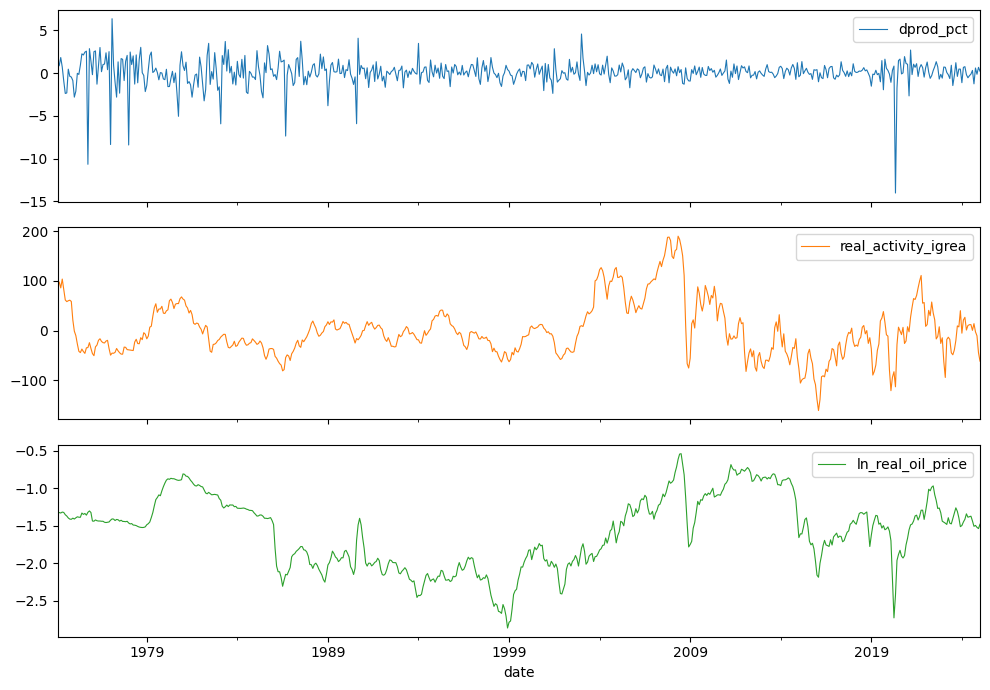

In [3]:
full[data_prep.VAR_COLUMNS].plot(subplots=True, figsize=(10, 7), lw=0.8); plt.tight_layout()

## Hormuz satellite transit data

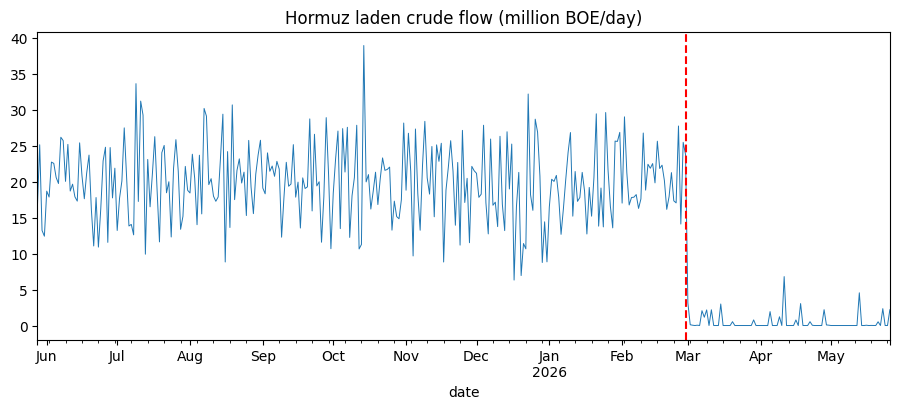

In [4]:
tidy = hormuz.parse_boil()
s = hormuz.daily_series(tidy, 'Crude Oil Tanker', 'west_east')/1e6
ax = s.plot(figsize=(11,4), lw=0.7, title='Hormuz laden crude flow (million BOE/day)')
ax.axvline(hormuz.DECLINE_START, color='red', ls='--');

In [5]:
hormuz.disruption_metrics(tidy)

DisruptionMetrics(tanker_type='Crude Oil Tanker', baseline_boe_per_day=19869713.922065217, post_boe_per_day=742861.6820454546, decline_pct=96.26133680153033, n_post_days=88, cumulative_shortfall_boe=1687092481.129674, days_of_consumption={'China': 83.10800399653566, 'USA': 104.78835286519714, 'EU': 160.6754743933023, 'Global': 16.12899121538885})

In [6]:
hormuz.validate_against_workbook(tidy)

{'baseline_boe_per_day': 19869713.922065217,
 'workbook_baseline': 19883899.78,
 'baseline_match_pct': 99.9286565608772,
 'actual_boe_since_decline': 65371828.02,
 'workbook_actual': 41572630.09,
 'shortfall_94d_boe': 1802381280.6541305,
 'workbook_shortfall': 1827513950.0,
 'shortfall_match_pct': 98.6247618330974}